<a href="https://colab.research.google.com/github/mominaiman27-m/Employee-salary-prediction/blob/main/knn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv('Social_Network_Ads.csv')
print(data.head())
print(data.shape)

   Age  EstimatedSalary  Purchased
0   19            19000          0
1   35            20000          0
2   26            43000          0
3   27            57000          0
4   19            76000          0
(400, 3)


In [ ]:
x=data.iloc[:,0:2].values
y=data.iloc[:,2].values
print(x)
print(y)


[[    19  19000]
 [    35  20000]
 [    26  43000]
 [    27  57000]
 [    19  76000]
 [    27  58000]
 [    27  84000]
 [    32 150000]
 [    25  33000]
 [    35  65000]
 [    26  80000]
 [    26  52000]
 [    20  86000]
 [    32  18000]
 [    18  82000]
 [    29  80000]
 [    47  25000]
 [    45  26000]
 [    46  28000]
 [    48  29000]
 [    45  22000]
 [    47  49000]
 [    48  41000]
 [    45  22000]
 [    46  23000]
 [    47  20000]
 [    49  28000]
 [    47  30000]
 [    29  43000]
 [    31  18000]
 [    31  74000]
 [    27 137000]
 [    21  16000]
 [    28  44000]
 [    27  90000]
 [    35  27000]
 [    33  28000]
 [    30  49000]
 [    26  72000]
 [    27  31000]
 [    27  17000]
 [    33  51000]
 [    35 108000]
 [    30  15000]
 [    28  84000]
 [    23  20000]
 [    25  79000]
 [    27  54000]
 [    30 135000]
 [    31  89000]
 [    24  32000]
 [    18  44000]
 [    29  83000]
 [    35  23000]
 [    27  58000]
 [    24  55000]
 [    23  48000]
 [    28  79000]
 [    22  1800

In [ ]:
x.shape

(400, 2)

In [ ]:
y.shape

(400,)

### Train-Test Split

It's crucial to split your data into training and testing sets. The training set is used to train your machine learning model, and the test set is used to evaluate its performance on unseen data. This helps in assessing how well your model generalizes.

We'll use `train_test_split` from `sklearn.model_selection` to achieve this. `test_size=0.2` means 20% of the data will be used for testing, and `random_state=0` ensures reproducibility of the split.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

print(f"x_train shape: {x_train.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

x_train shape: (320, 2)
x_test shape: (80, 2)
y_train shape: (320,)
y_test shape: (80,)


### Feature Scaling

Many machine learning algorithms, especially those that calculate distances between data points (like K-Nearest Neighbors), perform much better when the features are on a similar scale. `StandardScaler` from `sklearn.preprocessing` transforms your data such that it has a mean of 0 and a standard deviation of 1.

It's important to `fit` the scaler only on the training data (`x_train`) to prevent data leakage from the test set, and then `transform` both the training and test sets using that fitted scaler.

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

#print(f"x_train_scaled (first 5 rows):\n{x_train_scaled[:5]}")
#print(f"x_test_scaled (first 5 rows):\n{x_test_scaled[:5]}")

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [ ]:
x_train.shape

(320, 2)

In [ ]:
x_test.shape

(80, 2)

In [ ]:
#from sklearn.preprocessing import StandardScaler
#sc=StandardScaler()
#x_train_scaled=sc.fit_transform(x_train)
#x_test_scaled=sc.transform(x_test)

In [ ]:
np.sqrt(x_train_scaled.shape[0])

np.float64(17.88854381999832)

In [ ]:
k=17
from sklearn.neighbors import KNeighborsClassifier
classifier=KNeighborsClassifier(n_neighbors=k,metric='minkowski',p=2)
classifier.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=17)

In [ ]:
y_pred=classifier.predict(x_test_scaled)
y_pred.shape
y_test.shape

(80,)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.95

[[55  3]
 [ 1 21]]


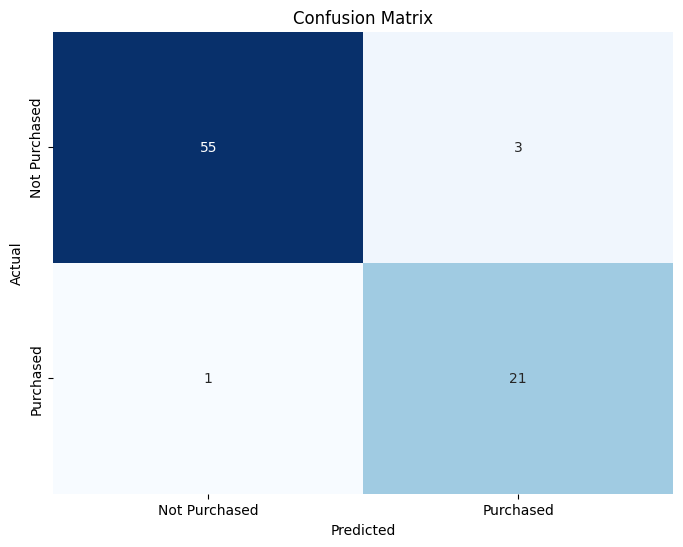

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Purchased', 'Purchased'], yticklabels=['Not Purchased', 'Purchased'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
accuracy=[]


for i in range(1,26):
    classifier=KNeighborsClassifier(n_neighbors=i,metric='minkowski',p=2)
    classifier.fit(x_train_scaled,y_train)
    accuracy.append(accuracy_score(y_test,classifier.predict(x_test_scaled)))
print(accuracy)

[0.875, 0.8875, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]


In [ ]:
len(accuracy)

25

In [ ]:
plt.plot(range(1,26),accuracy)
plt.xlabel('k value')
plt.ylabel('accuracy')
plt.show()

In [ ]:
def predict_output():
  age=int(input('Enter the age: '))
  salary=int(input('Enter the salary: '))

  x_new=np.array([[age,salary]]).reshape(1,2) #bcoz input columns are 2 age and salary
  x_new=sc.transform(x_new)

  if classifier.predict(x_new)[0]==0:
    return 'Not Purchased'
  else:
    return 'Purchased'

 # return classifier.predict(x_new)[0]



In [ ]:
predict_output()

In [ ]:
predict_output()

In [ ]:
DONE WITH THE PROJECT FINALLY YAYYYYYYYYYYYYYYYYYYYY!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

In [ ]:
#Applying decision boundry
#creating meshgrid
#age column oth column all rows and from very minimum value
a=np.arange(start=x_train_scaled[:,0].min()-1,stop=x_train_scaled[:,0].max()+1,step=0.01)
print(a)
a.shape
b=np.arange(start=x_train_scaled[:,1].min()-1,stop=x_train_scaled[:,1].max()+1,step=0.01)
print(b)
b.shape

xx,yy=np.meshgrid(a,b)
print(xx)
print(yy)
xx.shape
yy.shape

[[-2.96547978 -2.95547978 -2.94547978 ...  3.09452022  3.10452022
   3.11452022]
 [-2.96547978 -2.95547978 -2.94547978 ...  3.09452022  3.10452022
   3.11452022]
 [-2.96547978 -2.95547978 -2.94547978 ...  3.09452022  3.10452022
   3.11452022]
 ...
 [-2.96547978 -2.95547978 -2.94547978 ...  3.09452022  3.10452022
   3.11452022]
 [-2.96547978 -2.95547978 -2.94547978 ...  3.09452022  3.10452022
   3.11452022]
 [-2.96547978 -2.95547978 -2.94547978 ...  3.09452022  3.10452022
   3.11452022]]
[[-2.59138156 -2.59138156 -2.59138156 ... -2.59138156 -2.59138156
  -2.59138156]
 [-2.58138156 -2.58138156 -2.58138156 ... -2.58138156 -2.58138156
  -2.58138156]
 [-2.57138156 -2.57138156 -2.57138156 ... -2.57138156 -2.57138156
  -2.57138156]
 ...
 [ 3.29861844  3.29861844  3.29861844 ...  3.29861844  3.29861844
   3.29861844]
 [ 3.30861844  3.30861844  3.30861844 ...  3.30861844  3.30861844
   3.30861844]
 [ 3.31861844  3.31861844  3.31861844 ...  3.31861844  3.31861844
   3.31861844]]


(592, 609)

In [ ]:
yy.shape

(592, 609)

In [ ]:
592*609 #total customers

360528

In [ ]:
print(yy[0][0])
print(xx[0][0])

classifier.predict(np.array([-2.9654797790006904,-2.5913815646031484]).reshape(1,2))


-2.5913815646031484
-2.9654797790006904


array([0])

In [ ]:
input_array=np.array([xx.ravel(),yy.ravel()]).T

labels=classifier.predict(input_array)

In [ ]:
labels

array([0, 0, 0, ..., 1, 1, 1])

(-2.5913815646031484, 3.3186184353967256)

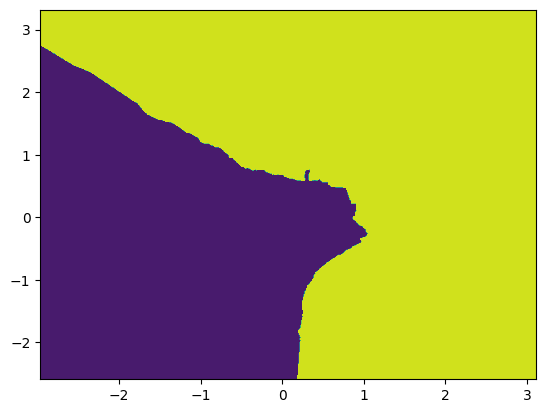

In [ ]:
plt.contourf(xx,yy,labels.reshape(xx.shape))
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())

(-2.5913815646031484, 3.3186184353967256)

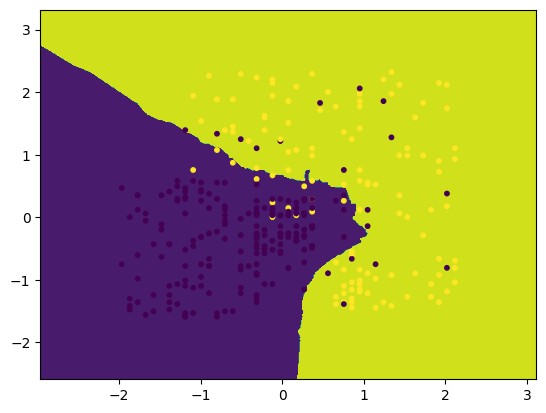

In [ ]:
plt.contourf(xx,yy,labels.reshape(xx.shape),alpha=1) #the aplha value is between o and 1 only
plt.scatter(x_train_scaled[:,0],x_train_scaled[:,1],c=y_train,s=10) #plotting all points predicted and trained graph
plt.xlim(xx.min(),xx.max())
plt.ylim(yy.min(),yy.max())